# Random Walks in Time Series Forecasting

**Numerik 25/26 – Projekt-Notebook**

Dieses Notebook enthält kleine, reproduzierbare Experimente zu Random Walks und deren Bedeutung für Time Series Forecasting.

Ziel:
- Random Walks simulieren
- Stationarität untersuchen
- Naive Forecasts testen
- Random Walk mit Drift vergleichen
- Prognosefehler analysieren
- Ergebnisse für eine kurze Präsentation visualisieren


## 1. Imports und Einstellungen

Wir verwenden nur Standardbibliotheken, die in Jupyter, Kaggle oder Google Colab normalerweise verfügbar sind.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


## 2. Was ist ein Random Walk?

Ein einfacher Random Walk ist definiert durch:

\[
X_t = X_{t-1} + \varepsilon_t
\]

Dabei ist:
- \(X_t\): aktueller Wert der Zeitreihe
- \(X_{t-1}\): vorheriger Wert
- \(\varepsilon_t\): zufälliger Fehler / Schock

Der nächste Wert entsteht also aus dem vorherigen Wert plus einem zufälligen Schritt.


In [2]:
def simulate_random_walk(n=200, start=0, sigma=1):
    """Simulate a simple random walk X_t = X_{t-1} + epsilon_t."""
    noise = np.random.normal(loc=0, scale=sigma, size=n)
    series = np.zeros(n)
    series[0] = start

    for t in range(1, n):
        series[t] = series[t - 1] + noise[t]

    return series, noise

n = 200
rw, noise = simulate_random_walk(n=n, start=0, sigma=1)

df = pd.DataFrame({
    "time": np.arange(n),
    "random_walk": rw,
    "noise": noise
})

df.head()


,time,random_walk,noise
0,0,0.000000,0.496714
1,1,-0.138264,-0.138264
2,2,0.509424,0.647689
3,3,2.032454,1.523030
4,4,1.798301,-0.234153


## 3. Experiment 1: Ein einzelner Random Walk

Ein Random Walk sieht oft so aus, als hätte er Trends oder Muster.  
Diese Muster entstehen aber nur durch die aufsummierten Zufallsschritte.


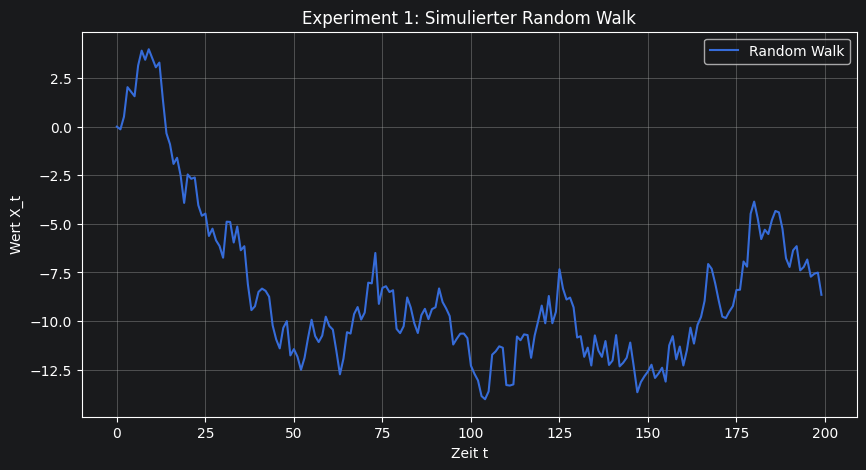

In [3]:
plt.figure()
plt.plot(df["time"], df["random_walk"], label="Random Walk")
plt.title("Experiment 1: Simulierter Random Walk")
plt.xlabel("Zeit t")
plt.ylabel("Wert X_t")
plt.legend()
plt.show()


## 4. Experiment 2: Mehrere Random Walks

Wenn man mehrere Random Walks simuliert, sieht man:  
Sie starten gleich, können sich aber sehr unterschiedlich entwickeln.


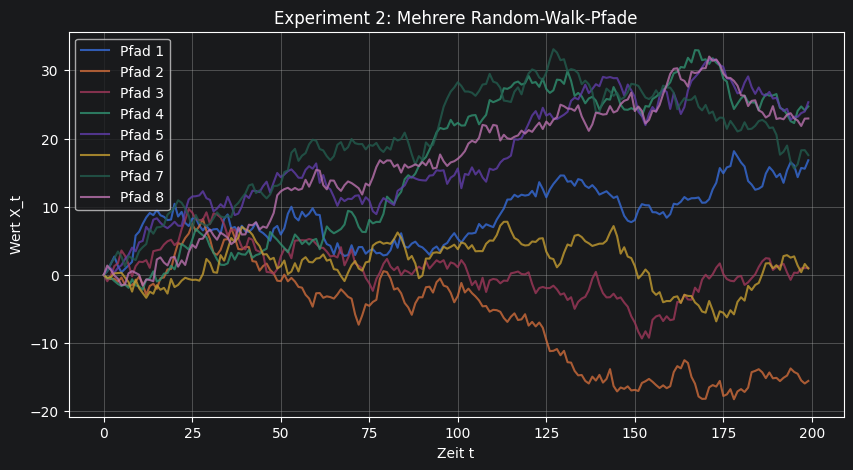

In [4]:
plt.figure()

for i in range(8):
    series, _ = simulate_random_walk(n=200, start=0, sigma=1)
    plt.plot(series, alpha=0.8, label=f"Pfad {i+1}")

plt.title("Experiment 2: Mehrere Random-Walk-Pfade")
plt.xlabel("Zeit t")
plt.ylabel("Wert X_t")
plt.legend()
plt.show()


## 5. Experiment 3: Stationarität prüfen

Viele klassische Forecasting-Methoden setzen voraus, dass eine Zeitreihe stationär ist.

Ein Random Walk ist typischerweise **nicht stationär**, weil sich seine Varianz über die Zeit verändert.

Wir verwenden hier den Augmented Dickey-Fuller Test:

- Nullhypothese: Die Zeitreihe besitzt eine Unit Root, also ist sie nicht stationär.
- Wenn der p-Wert groß ist, können wir Nicht-Stationarität nicht verwerfen.


In [5]:
adf_result = adfuller(df["random_walk"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")

if adf_result[1] < 0.05:
    print("\nInterpretation: Die Reihe wirkt stationär.")
else:
    print("\nInterpretation: Die Reihe wirkt nicht stationär.")


ADF Statistic: -2.307285179064525
p-value: 0.16962912078943748
Critical Values:
  1%: -3.4636447617687436
  5%: -2.8761761179270766
  10%: -2.57457158581854

Interpretation: Die Reihe wirkt nicht stationär.


## 6. Differenzieren des Random Walks

Wenn wir die Differenzen bilden,

\[
\Delta X_t = X_t - X_{t-1}
\]

erhalten wir im einfachen Fall wieder ungefähr das Rauschen \(\varepsilon_t\).  
Die differenzierte Reihe ist normalerweise stationärer als der ursprüngliche Random Walk.


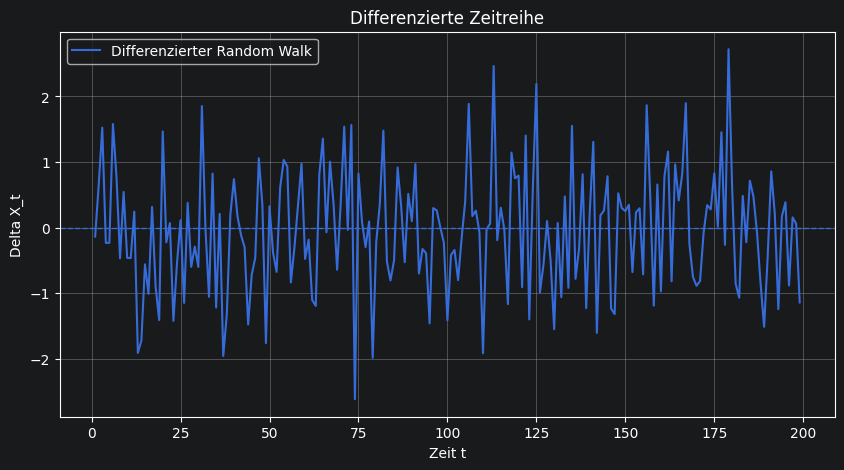

In [6]:
df["difference"] = df["random_walk"].diff()

plt.figure()
plt.plot(df["time"], df["difference"], label="Differenzierter Random Walk")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Differenzierte Zeitreihe")
plt.xlabel("Zeit t")
plt.ylabel("Delta X_t")
plt.legend()
plt.show()


In [7]:
diff_series = df["difference"].dropna()

adf_diff_result = adfuller(diff_series)

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])
print("Critical Values:")
for key, value in adf_diff_result[4].items():
    print(f"  {key}: {value}")

if adf_diff_result[1] < 0.05:
    print("\nInterpretation: Die differenzierte Reihe wirkt stationär.")
else:
    print("\nInterpretation: Die differenzierte Reihe wirkt nicht stationär.")


ADF Statistic: -14.691774924143179
p-value: 3.0415339027296236e-27
Critical Values:
  1%: -3.4638151713286316
  5%: -2.876250632135043
  10%: -2.574611347821651

Interpretation: Die differenzierte Reihe wirkt stationär.


## 7. Experiment 4: Naive Forecast

Bei einem Random Walk ist ein sehr wichtiger Forecast:

\[
\hat{X}_{t+1} = X_t
\]

Das bedeutet:  
Der beste einfache Schätzer für morgen ist der heutige Wert.

Das nennt man **naive forecast** oder **persistence model**.


In [8]:
train_size = int(0.8 * n)

train = df["random_walk"].iloc[:train_size]
test = df["random_walk"].iloc[train_size:]

# Naive forecast: previous observed value
naive_forecast = df["random_walk"].shift(1).iloc[train_size:]

comparison = pd.DataFrame({
    "actual": test.values,
    "naive_forecast": naive_forecast.values
}, index=test.index)

comparison.head()


,actual,naive_forecast
160,-12.287677,-11.312996
161,-11.500593,-12.287677
162,-10.341997,-11.500593
163,-11.162679,-10.341997
164,-10.199303,-11.162679


In [9]:
mae = mean_absolute_error(comparison["actual"], comparison["naive_forecast"])
rmse = np.sqrt(mean_squared_error(comparison["actual"], comparison["naive_forecast"]))

print("Naive Forecast Performance")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))


Naive Forecast Performance
MAE : 0.7239
RMSE: 0.9033


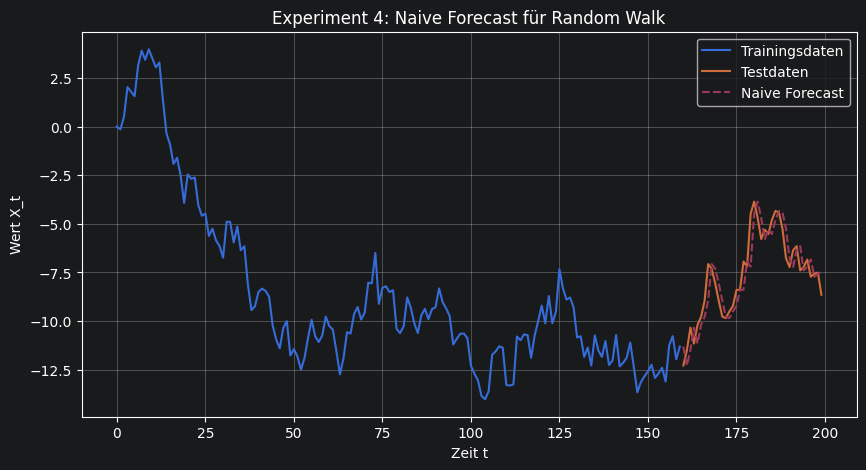

In [10]:
plt.figure()
plt.plot(train.index, train.values, label="Trainingsdaten")
plt.plot(test.index, test.values, label="Testdaten")
plt.plot(comparison.index, comparison["naive_forecast"], linestyle="--", label="Naive Forecast")
plt.title("Experiment 4: Naive Forecast für Random Walk")
plt.xlabel("Zeit t")
plt.ylabel("Wert X_t")
plt.legend()
plt.show()


## 8. Experiment 5: Random Walk mit Drift

Ein Random Walk mit Drift hat zusätzlich eine durchschnittliche Richtung:

\[
X_t = X_{t-1} + \mu + \varepsilon_t
\]

Dabei ist \(\mu\) der Drift.


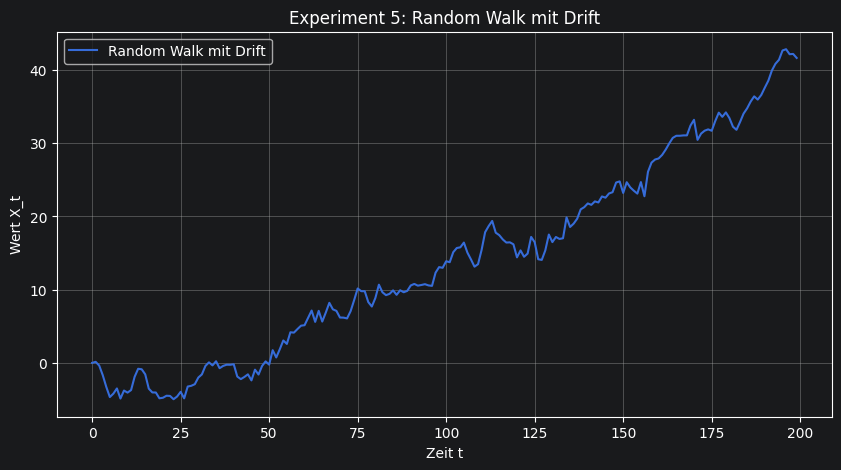

In [11]:
def simulate_random_walk_with_drift(n=200, start=0, drift=0.2, sigma=1):
    noise = np.random.normal(loc=0, scale=sigma, size=n)
    series = np.zeros(n)
    series[0] = start

    for t in range(1, n):
        series[t] = series[t - 1] + drift + noise[t]

    return series, noise

rw_drift, noise_drift = simulate_random_walk_with_drift(n=200, start=0, drift=0.2, sigma=1)

plt.figure()
plt.plot(rw_drift, label="Random Walk mit Drift")
plt.title("Experiment 5: Random Walk mit Drift")
plt.xlabel("Zeit t")
plt.ylabel("Wert X_t")
plt.legend()
plt.show()


## 9. Forecast mit geschätztem Drift

Wir schätzen den Drift als durchschnittliche Veränderung in den Trainingsdaten.

Dann lautet der Forecast:

\[
\hat{X}_{t+1} = X_t + \hat{\mu}
\]


In [12]:
df_drift = pd.DataFrame({
    "time": np.arange(n),
    "random_walk_drift": rw_drift
})

df_drift["difference"] = df_drift["random_walk_drift"].diff()

train_drift = df_drift["random_walk_drift"].iloc[:train_size]
test_drift = df_drift["random_walk_drift"].iloc[train_size:]

estimated_drift = df_drift["difference"].iloc[1:train_size].mean()

forecast_drift = df_drift["random_walk_drift"].shift(1).iloc[train_size:] + estimated_drift

comparison_drift = pd.DataFrame({
    "actual": test_drift.values,
    "forecast_with_drift": forecast_drift.values
}, index=test_drift.index)

print("Estimated drift:", round(estimated_drift, 4))
comparison_drift.head()


Estimated drift: 0.1747


,actual,forecast_with_drift
160,27.916673,27.946231
161,28.402227,28.091337
162,29.123350,28.576891
163,29.968565,29.298013
164,30.724170,30.143229


In [13]:
mae_drift = mean_absolute_error(comparison_drift["actual"], comparison_drift["forecast_with_drift"])
rmse_drift = np.sqrt(mean_squared_error(comparison_drift["actual"], comparison_drift["forecast_with_drift"]))

print("Forecast with Drift Performance")
print("MAE :", round(mae_drift, 4))
print("RMSE:", round(rmse_drift, 4))


Forecast with Drift Performance
MAE : 0.66
RMSE: 0.8313


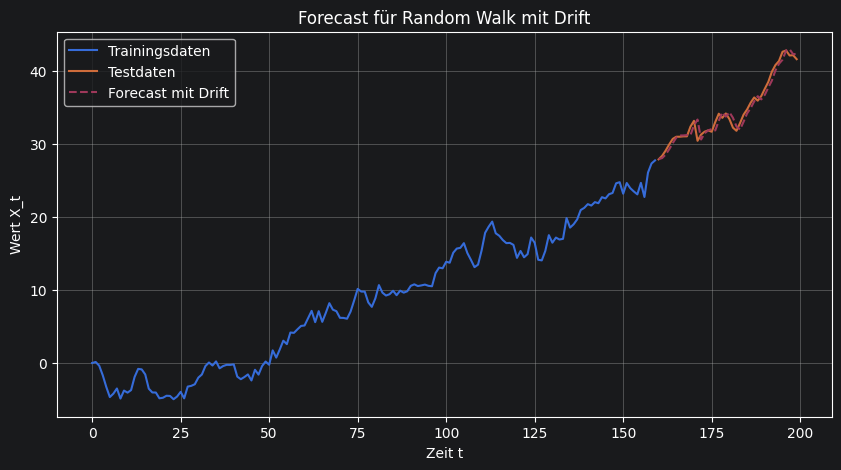

In [14]:
plt.figure()
plt.plot(train_drift.index, train_drift.values, label="Trainingsdaten")
plt.plot(test_drift.index, test_drift.values, label="Testdaten")
plt.plot(comparison_drift.index, comparison_drift["forecast_with_drift"], linestyle="--", label="Forecast mit Drift")
plt.title("Forecast für Random Walk mit Drift")
plt.xlabel("Zeit t")
plt.ylabel("Wert X_t")
plt.legend()
plt.show()


## 10. Experiment 6: Vergleich der Fehlerverteilung

Bei Random Walks sind Prognosefehler unvermeidbar, weil jeder neue Schritt einen zufälligen Schock enthält.


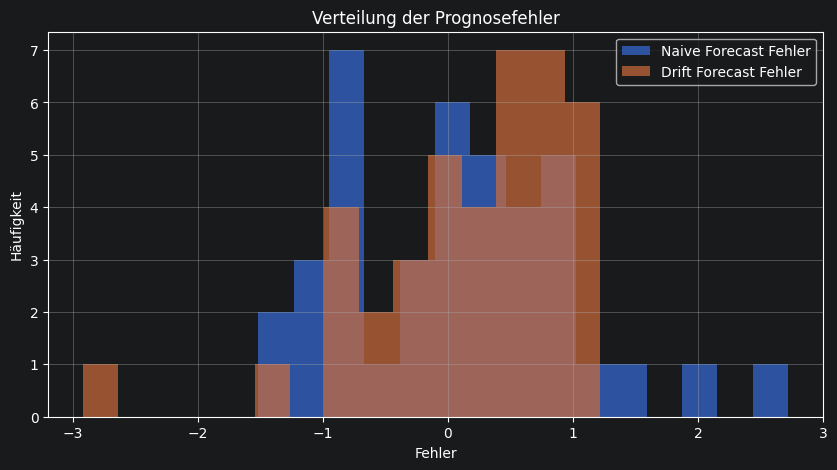

In [15]:
comparison["error"] = comparison["actual"] - comparison["naive_forecast"]
comparison_drift["error"] = comparison_drift["actual"] - comparison_drift["forecast_with_drift"]

plt.figure()
plt.hist(comparison["error"], bins=15, alpha=0.7, label="Naive Forecast Fehler")
plt.hist(comparison_drift["error"], bins=15, alpha=0.7, label="Drift Forecast Fehler")
plt.title("Verteilung der Prognosefehler")
plt.xlabel("Fehler")
plt.ylabel("Häufigkeit")
plt.legend()
plt.show()


## 11. Experiment 7: Warum langfristige Forecasts schwierig sind

Bei einem Random Walk wächst die Unsicherheit mit dem Forecast-Horizont.  
Je weiter wir in die Zukunft prognostizieren, desto breiter wird der mögliche Wertebereich.


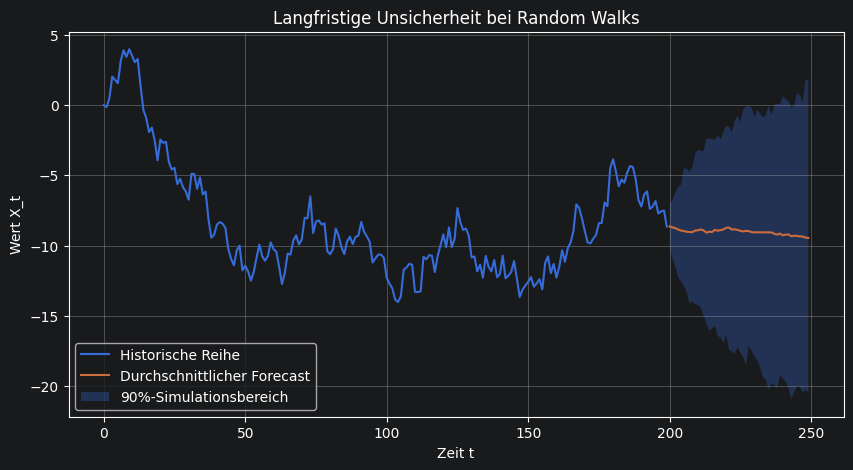

In [16]:
last_value = df["random_walk"].iloc[-1]
horizon = 50
num_simulations = 200

future_paths = []

for i in range(num_simulations):
    future_noise = np.random.normal(0, 1, horizon)
    future_path = last_value + np.cumsum(future_noise)
    future_paths.append(future_path)

future_paths = np.array(future_paths)

mean_forecast = future_paths.mean(axis=0)
lower_bound = np.percentile(future_paths, 5, axis=0)
upper_bound = np.percentile(future_paths, 95, axis=0)

future_index = np.arange(n, n + horizon)

plt.figure()
plt.plot(df["random_walk"], label="Historische Reihe")
plt.plot(future_index, mean_forecast, label="Durchschnittlicher Forecast")
plt.fill_between(future_index, lower_bound, upper_bound, alpha=0.3, label="90%-Simulationsbereich")
plt.title("Langfristige Unsicherheit bei Random Walks")
plt.xlabel("Zeit t")
plt.ylabel("Wert X_t")
plt.legend()
plt.show()


## 12. Wichtigste Erkenntnisse für die Präsentation

1. Ein Random Walk entsteht durch das Aufsummieren zufälliger Schritte.
2. Random Walks sind meistens nicht stationär.
3. Nach dem Differenzieren wird die Reihe oft stationär.
4. Für einen einfachen Random Walk ist der naive Forecast sehr wichtig:
   Der nächste Wert wird als letzter beobachteter Wert geschätzt.
5. Bei Random Walks wächst die Unsicherheit mit dem Prognosehorizont.
6. Random Walks sind ein wichtiges Basismodell in Time Series Forecasting, besonders bei Aktienkursen, Preisen und anderen schwer vorhersagbaren Prozessen.


## 13. Kurzes deutsches Skript für die Vorstellung der Experimente

**Experiment 1:**  
„Hier sehen wir einen simulierten Random Walk. Jeder neue Wert entsteht aus dem vorherigen Wert plus einem zufälligen Fehler. Obwohl die Kurve wie ein Trend aussieht, entsteht sie nur durch Zufallsschritte.“

**Experiment 2:**  
„Wenn wir mehrere Random Walks simulieren, sehen wir, dass sich die Pfade sehr unterschiedlich entwickeln können. Das zeigt, wie stark der Zufall die langfristige Entwicklung beeinflusst.“

**Experiment 3:**  
„Mit dem Augmented-Dickey-Fuller-Test prüfen wir die Stationarität. Der ursprüngliche Random Walk ist normalerweise nicht stationär. Nach dem Differenzieren wird die Reihe deutlich stationärer.“

**Experiment 4:**  
„Für Random Walks ist ein einfacher, aber wichtiger Forecast der naive Forecast. Dabei wird der nächste Wert als letzter beobachteter Wert geschätzt.“

**Experiment 5:**  
„Beim Random Walk mit Drift gibt es zusätzlich eine durchschnittliche Richtung. Der Forecast kann deshalb um den geschätzten Drift erweitert werden.“

**Experiment 6:**  
„Die Fehleranalyse zeigt, dass Prognosefehler unvermeidbar sind, weil zukünftige Zufallsschocks unbekannt bleiben.“

**Experiment 7:**  
„Zum Schluss sieht man, dass die Unsicherheit mit dem Forecast-Horizont wächst. Je weiter wir in die Zukunft gehen, desto unsicherer wird die Prognose.“
